# Combine All Datasets

> One dataset to rule them all, and in the darkness, bind them.

In [1]:
%load_ext autoreload
%autoreload 2

from helpers import plotLightCurveFromDF, saveLightCurveFromDF, sampleRandomKIC


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline


---

In [3]:
%%time
K2VARCAT = pd.read_pickle(r"../data/saved-dataframes/K2VARCAT-C-00.pkl")
KCC = pd.read_parquet(r"../data/saved-dataframes/KCC-stitched.parquet")
KEB = pd.read_pickle(r"../data/saved-dataframes/KEB.pkl")


CPU times: user 7.47 s, sys: 5.3 s, total: 12.8 s
Wall time: 8.8 s


---

## Format the K2 Variable Catalog

1. Change classes
2. Drop unnecessary columns
3. Save new parquet set

In [4]:
K2VARCAT.shape


(7748, 13)

In [5]:
K2VARCAT.index.name = "KIC"
K2VARCAT = K2VARCAT.drop(columns=["Campaign"])



In [6]:
print(K2VARCAT['Class'].value_counts())


Class
 Noise    4476
OTHPER    2548
 DSCUT     263
  GDOR     161
    EA     149
    EB     143
  RRab       8
Name: count, dtype: int64


<Axes: >

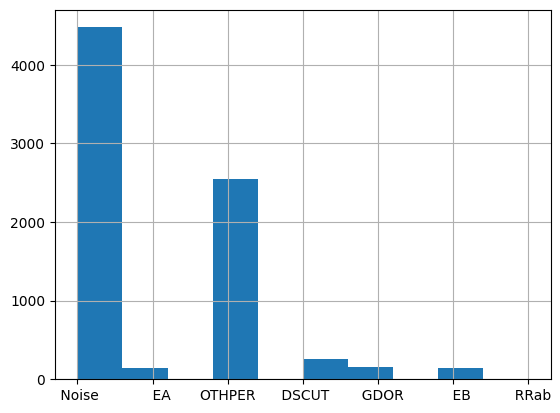

In [7]:
K2VARCAT['Class'].hist()


In [8]:
K2VARCAT["Class_clean"] = K2VARCAT["Class"].astype(str).str.strip().str.upper()
K2VARCAT["Class_new"] = "Variable Star"

# Apply rules
K2VARCAT.loc[
    K2VARCAT["Class_clean"].isin(["EA", "EB"]),
    "Class_new"
] = "Eclipsing Binary Star"

K2VARCAT.loc[
    K2VARCAT["Class_clean"] == "NOISE",
    "Class_new"
] = "False Positive"

# Replace original column
K2VARCAT = K2VARCAT.drop(columns=["Class"]).rename(columns={"Class_new": "Class"})


In [9]:
K2VARCAT['Class'].value_counts()


Class
False Positive           4476
Variable Star            2980
Eclipsing Binary Star     292
Name: count, dtype: int64

<Axes: >

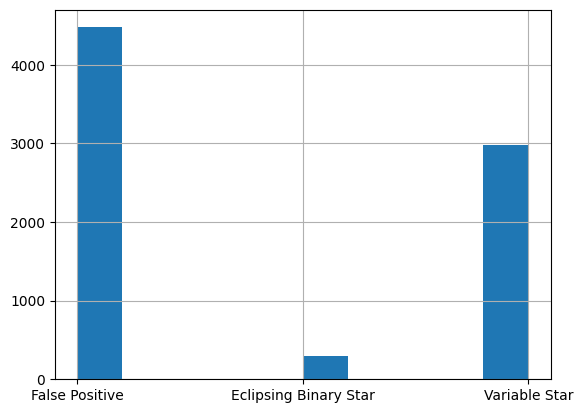

In [10]:
K2VARCAT['Class'].hist()


In [11]:
temp = (
    K2VARCAT
    .reset_index()
    [["KIC", "time", "flux", "Class"]]
)


In [12]:
K2VARCAT = temp.set_index("KIC")


In [13]:
K2VARCAT


,time,flux,Class
KIC,,,
202059070,"[1940.02801180377, 1940.0484434910104, 1940.06...","[1.0209611654281616, 0.999671220779419, 1.0258...",False Positive
202059073,"[1940.0078166502353, 1940.02824824032, 1940.04...","[0.9937425851821899, 0.99190354347229, 0.99378...",False Positive
202059074,"[1940.0078458546486, 1940.0487091504256, 1940....","[0.9949902296066284, 0.9948084354400635, 0.995...",False Positive
202059078,"[1940.0084669657808, 1940.0288985853185, 1940....","[0.9812511205673218, 0.9826586246490479, 0.979...",False Positive
202059080,"[1940.0084856754693, 1940.0289172976845, 1940....","[0.9239972829818726, 0.8829833269119263, 0.904...",False Positive
...,...,...,...
202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",Variable Star
202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",Variable Star
202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",False Positive


In [14]:
# K2VARCAT.to_parquet("./local-assets/K2VARCAT_cleaned.parquet")


--- Plotting Light Curve for KIC 202137227 ---


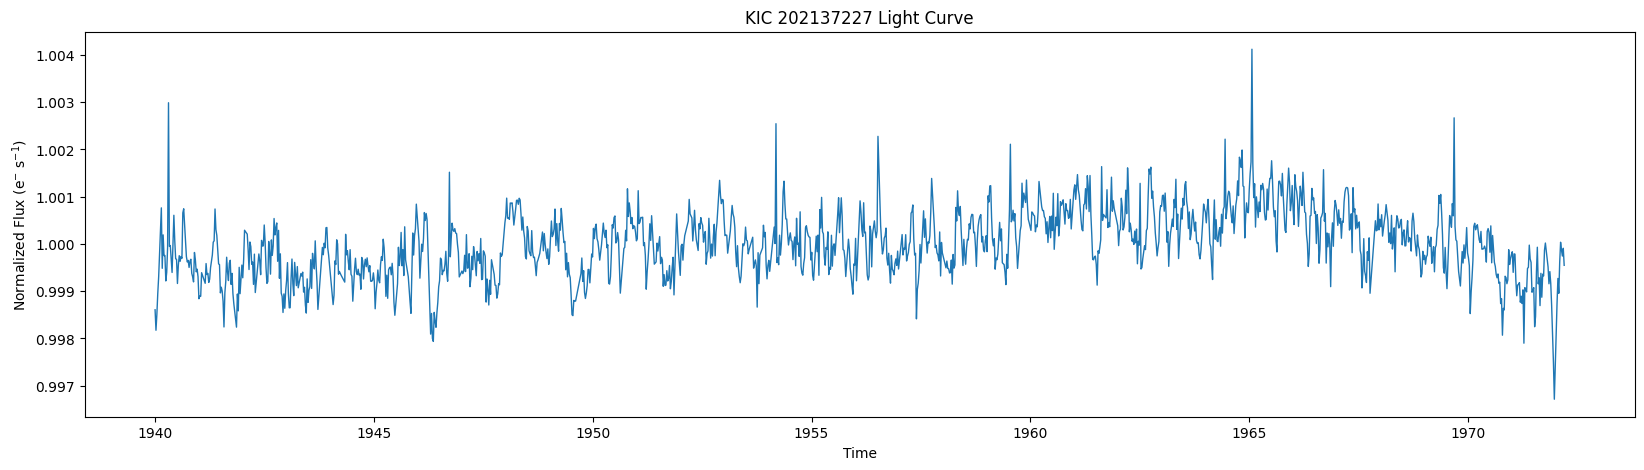

CPU times: user 67.7 ms, sys: 3.41 ms, total: 71.2 ms
Wall time: 73 ms


In [15]:
%%time
kic = sampleRandomKIC(K2VARCAT)
print(f"--- Plotting Light Curve for KIC {kic} ---")

plotLightCurveFromDF(K2VARCAT, kic)


---

## Format the Kepler KOI Cumulative Catalog

In [16]:
KCC


,time,flux,flux_err,n_points
KIC,,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[11763.091796875, 11753.1396484375, 11758.1083...","[5.091228008270264, 5.097338676452637, 5.09830...",64795
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[12429.0693359375, 12420.267578125, 12422.0224...","[5.391023635864258, 5.388980865478516, 5.38850...",54967
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1312166.625, 1316493.0, 1315990.125, 1315446....","[31.843351364135742, 31.811965942382812, 31.78...",65264
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[17661.986328125, 17651.8203125, 17646.8378906...","[5.714937686920166, 5.722585201263428, 5.72262...",64795
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[135977.390625, 135878.828125, 135846.390625, ...","[12.252449035644531, 12.239001274108887, 12.22...",65264
...,...,...,...,...
12833566,"[120.53884536049009, 120.55927955194056, 120.5...","[615853.125, 615784.8125, 615820.875, 615831.1...","[23.11433982849121, 23.04035186767578, 23.0623...",65264
12834874,"[131.51196432943107, 131.53239862471673, 131.5...","[20523.1484375, 20518.134765625, 20502.9824218...","[6.4272379875183105, 6.423366546630859, 6.4251...",64795
12835139,"[120.53879223243712, 120.55922643133817, 120.5...","[51060.73046875, 51034.3828125, 51043.015625, ...","[8.577451705932617, 8.549298286437988, 8.55790...",65264


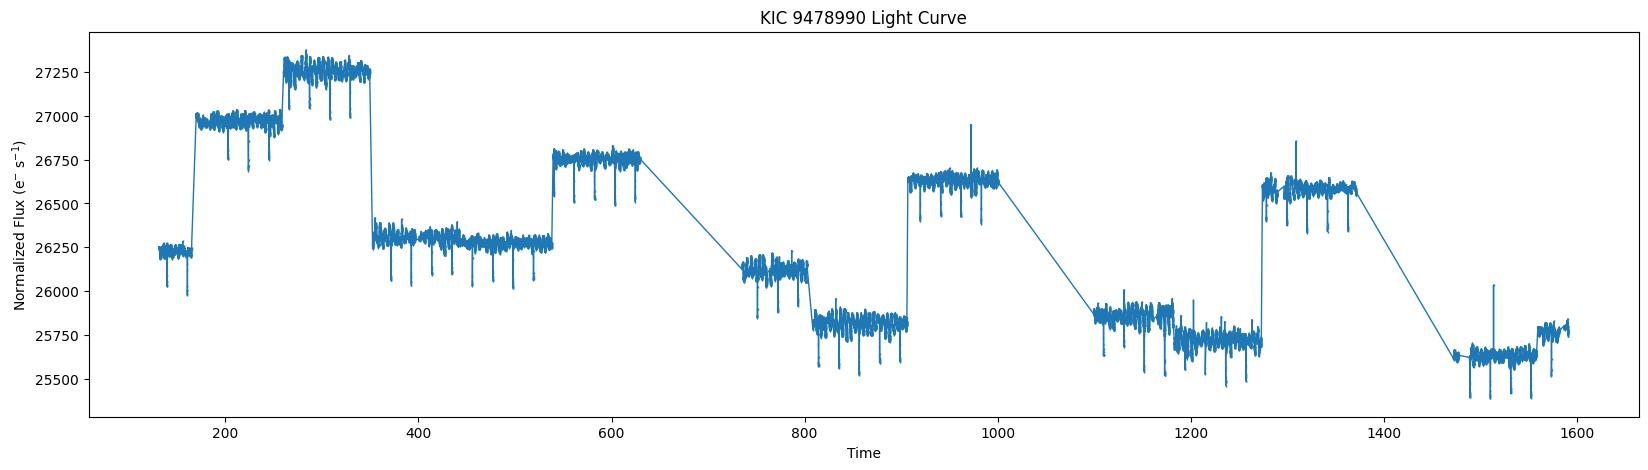

In [21]:
kic = sampleRandomKIC(KCC)
plotLightCurveFromDF(KCC, kic)
